<a href="https://colab.research.google.com/github/sumitasthana/hypernetworks/blob/main/Scalable_Hypernetworks_for_Long_Sequence_Continual_Unlearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Run before creating models or starting training.
# This replaces the earlier unfinished S0 configuration.
if globals().get("s1_initialized", False):
    raise RuntimeError(
        "S1 has already initialized this run. "
        "Use a fresh runtime before replacing the experiment configuration."
    )

if any(globals().get(name) is not None for name in ("hypernet", "classifier")):
    raise RuntimeError("Models already exist. Do not replace their configuration.")

config = {
    # We are checking whether the complete learning/forgetting process works.
    "experiment_name": "uncle_permuted_mnist_debug",
    "dataset": "Permuted-MNIST",
    "backbone": "resnet18",
    "pretrained": False,

    # Every task recognizes the same ten digits.
    # The difference between tasks is how their pixels are rearranged.
    "task_classes": {
        "A": list(range(10)),
        "B": list(range(10)),
        "C": list(range(10)),
    },
    "permutation_seeds": {
        "A": 101,
        "B": 102,
        "C": 103,
    },
    "requests": [
        ("learn", "A"),
        ("learn", "B"),
        ("forget", "A"),
        ("learn", "C"),
    ],
    "learn_each_task_once": True,

    # Split the original examples BEFORE making task permutations.
    # All tasks reuse these split boundaries to avoid data leakage.
    "split_plan": {
        "train": "90% of official MNIST training examples",
        "validation": "10% of official MNIST training examples",
        "test": "Official MNIST test examples",
    },
    "validation_fraction": 0.10,
    "stratified_split": True,
    "evaluation_split": "validation",
    "seed": 42,
    "split_seed": 42,

    # Development input policy: preserve the original 28 x 28 image size.
    "input_channels": 1,
    "image_size": 28,
    "pixel_scaling": "Convert pixels to floats in [0, 1]",
    "augmentation": "none",
    "resnet_stem": "3x3 convolution, stride 1, padding 1; no initial max-pool",

    # Short initial training run. Five epochs may not be enough to converge.
    "batch_size": 64,
    "epochs": 5,
    "num_workers": 0,
    "optimizer": "Adam",
    "learning_rate": 0.001,
    "scheduler": {"name": "constant"},
    "weight_decay": 0.0,

    # The paper's stated coefficients for Permuted-MNIST.
    "beta": 0.1,
    "gamma": 0.01,

    # Hypernetwork sizes reported in the paper.
    "hidden_widths": [128, 256, 512],
    "task_embedding_dim": 32,
    "chunk_embedding_dim": 32,
    "num_chunks": 200,

    # Our explicit reconstruction choices for weight generation.
    "hidden_activation": "ReLU",
    "embedding_initialization": "Independent standard normal values",
    "chunk_mapping": (
        "Within each output-head group, flatten parameters in a saved order. "
        "Allocate 200 chunks across groups in proportion to parameter count, "
        "with at least one per group. Pad each group's last chunk and discard "
        "padding when reconstructing parameter tensors."
    ),
    "output_head_mapping": {
        "batchnorm": "All BatchNorm affine parameters, including shortcut BatchNorm",
        "shortcut": "Shortcut projection convolution parameters",
        "main": "All remaining convolution and classifier parameters",
    },

    # This is a development approximation, NOT Hyperfan.
    "initialization": {
        "method": "conventional_initialization_with_output_scaling",
        "hidden_layers": "Kaiming normal for ReLU; zero biases",
        "output_heads": "Xavier normal; zero biases",
        "generated_weights": "Scale raw convolution/linear weights by sqrt(2/fan_in)",
        "generated_biases": "Scale raw biases by 0.01",
        "batchnorm_scale": "1 + 0.01 * raw output",
        "batchnorm_shift": "0.01 * raw output",
    },
    "hyperfan_initialization": "Not implemented in this development run",

    # Use the written equations' squared-distance reduction.
    # Do not accidentally replace the parameter sum with an elementwise mean.
    "loss_reduction": {
        "classification": "Mean cross-entropy over the current batch",
        "parameter_distance": "Sum of squared differences over actual parameters",
        "preservation": "Mean parameter distance over protected tasks",
        "noise": "Mean parameter distance over noise samples",
        "padding": "Exclude padded entries from all parameter losses",
        "empty_protected_set": "Zero preservation loss",
    },

    # Keep each task's running image statistics separate.
    "batchnorm_buffer_policy": (
        "Store running mean, variance, and batch counter per task. "
        "Update only while learning that task. Freeze during evaluation "
        "and unlearning."
    ),
    "optimizer_reset_policy": "Create a fresh Adam optimizer for each request",
    "snapshot_refresh_policy": (
        "Copy the current hypernetwork at the start of every request. "
        "Keep that reference fixed until the request finishes."
    ),
    "forgotten_task_protection": (
        "Protect previously forgotten tasks at their current generated weights "
        "during later requests. Exclude the task currently being forgotten."
    ),
    "chunk_embedding_policy": "Train on the first task only; freeze afterward",

    # Noise and forgetting settings.
    "noise_samples": 10,
    "noise_distribution": "standard_normal",
    "fresh_noise_each_update": True,
    "burn_in_start": 100,
    "burn_in_min": 20,
    "burn_in_decay": 0.9,
    "burn_in_rounding": "max(20, floor(100 * 0.9**k))",

    # Evaluation and storage.
    "accuracy_units": "percent",
    "spill_task_set": "All previously seen tasks except the current forget target",
    "output_dir": "/content/drive/MyDrive/uncle_experiment",
}

requests = config["requests"]
s0_ready = False

print("Configured experiment:", config["experiment_name"])
print("Request sequence:", requests)

Configured experiment: uncle_permuted_mnist_debug
Request sequence: [('learn', 'A'), ('learn', 'B'), ('forget', 'A'), ('learn', 'C')]


In [3]:
from IPython.display import Markdown, display

assumptions = [
    {
        "setting": "Model sizes, Adam learning rate, noise settings",
        "source": "Paper",
        "note": "Use the reported values recorded in config.",
    },
    {
        "setting": "Beta and gamma",
        "source": "Paper",
        "note": "Use the stated Permuted-MNIST values: 0.1 and 0.01.",
    },
    {
        "setting": "Three tasks, five epochs, batch size 64",
        "source": "Development choice",
        "note": "A short debugging run, not the full paper experiment.",
    },
    {
        "setting": "Seeds, split, constant learning rate",
        "source": "Development choice",
        "note": "Explicit choices for our first run.",
    },
    {
        "setting": "Small-image ResNet stem and input preprocessing",
        "source": "Reconstruction choice",
        "note": "Use one-channel 28 x 28 images; verify the authors' details later.",
    },
    {
        "setting": "Chunk allocation and output-head mapping",
        "source": "Reconstruction choice",
        "note": "The paper does not fully specify the parameter mapping.",
    },
    {
        "setting": "Initialization",
        "source": "Development deviation",
        "note": "Conventional initialization with output scaling, not Hyperfan.",
    },
    {
        "setting": "Loss reduction",
        "source": "Written paper equations",
        "note": "Sum squared parameter errors; average over tasks or noise samples.",
    },
    {
        "setting": "BatchNorm, optimizer resets, snapshot refresh",
        "source": "Reconstruction choice",
        "note": "Use the explicit policies in config.",
    },
    {
        "setting": "Protect previously forgotten tasks",
        "source": "Reconstruction choice",
        "note": "This may affect relapse and needs a later comparison.",
    },
    {
        "setting": "Burn-in rounding",
        "source": "Reconstruction choice",
        "note": "Round down after decay; never use fewer than 20 updates.",
    },
]

# Show a readable table without introducing a custom class or helper.
table = "| Setting | Source | Note |\n"
table += "| --- | --- | --- |\n"

for record in assumptions:
    table += (
        f"| {record['setting']} | {record['source']} | "
        f"{record['note']} |\n"
    )

display(Markdown(table))

| Setting | Source | Note |
| --- | --- | --- |
| Model sizes, Adam learning rate, noise settings | Paper | Use the reported values recorded in config. |
| Beta and gamma | Paper | Use the stated Permuted-MNIST values: 0.1 and 0.01. |
| Three tasks, five epochs, batch size 64 | Development choice | A short debugging run, not the full paper experiment. |
| Seeds, split, constant learning rate | Development choice | Explicit choices for our first run. |
| Small-image ResNet stem and input preprocessing | Reconstruction choice | Use one-channel 28 x 28 images; verify the authors' details later. |
| Chunk allocation and output-head mapping | Reconstruction choice | The paper does not fully specify the parameter mapping. |
| Initialization | Development deviation | Conventional initialization with output scaling, not Hyperfan. |
| Loss reduction | Written paper equations | Sum squared parameter errors; average over tasks or noise samples. |
| BatchNorm, optimizer resets, snapshot refresh | Reconstruction choice | Use the explicit policies in config. |
| Protect previously forgotten tasks | Reconstruction choice | This may affect relapse and needs a later comparison. |
| Burn-in rounding | Reconstruction choice | Round down after decay; never use fewer than 20 updates. |


In [4]:
from pathlib import PurePosixPath

s0_ready = False
requests = config["requests"]

# Check the main settings for this selected development experiment.
assert config["dataset"] == "Permuted-MNIST"
assert config["batch_size"] > 0
assert config["epochs"] > 0
assert 0 < config["validation_fraction"] < 1
assert PurePosixPath(config["output_dir"]).is_absolute()
assert config["evaluation_split"] == "validation"

# Each task must recognize all ten digits.
for task_id, classes in config["task_classes"].items():
    assert classes == list(range(10)), f"Wrong classes for task {task_id}."
    assert task_id in config["permutation_seeds"]

# Check the request sequence using temporary bookkeeping only.
# This does not create or modify the real training state.
check_seen = set()
check_retained = set()

for action, task_id in requests:
    assert task_id in config["task_classes"], f"Unknown task: {task_id}"

    if action == "learn":
        assert task_id not in check_seen, f"Task {task_id} is learned twice."
        check_seen.add(task_id)
        check_retained.add(task_id)

    elif action == "forget":
        assert task_id in check_retained, f"Task {task_id} is not retained."
        check_retained.remove(task_id)

    else:
        raise ValueError(f"Unknown action: {action}")

assert check_retained == {"B", "C"}

# S1 and S4 still need to check the actual runtime and model memory use.
s0_ready = True

print("S0 configuration checks passed.")
print("Final intended retained tasks: B and C.")
print("Final intended forgotten task: A.")
print("No data downloaded and no model trained.")
print("Next: S1.")

S0 configuration checks passed.
Final intended retained tasks: B and C.
Final intended forgotten task: A.
No data downloaded and no model trained.
Next: S1.


In [5]:
from pathlib import PurePosixPath
import math

# Always clear the flag before checking the current settings.
s0_ready = False
requests = config["requests"]
problems = []

# Every undecided setting must be filled in explicitly.
for setting, value in config.items():
    if value is None:
        problems.append(f"Missing setting: {setting}")

# Check seed ranges accepted by the S1 initialization code.
for setting in ("seed", "split_seed"):
    value = config[setting]

    if value is not None:
        if type(value) is not int or not 0 <= value < 2**32:
            problems.append(f"{setting} must be an integer from 0 to 2**32 - 1.")

# Check basic training settings.
for setting in ("batch_size", "epochs"):
    value = config[setting]

    if value is not None:
        if type(value) is not int or value <= 0:
            problems.append(f"{setting} must be a positive integer.")

for setting in ("beta", "gamma"):
    value = config[setting]

    if value is not None:
        valid_number = type(value) in (int, float)

        if not valid_number or not math.isfinite(value) or value <= 0:
            problems.append(f"{setting} must be a finite positive number.")

# Check the output path without creating any folders.
output_path = config["output_dir"]

if output_path is not None:
    if not isinstance(output_path, str) or not output_path.strip():
        problems.append("output_dir must be a nonempty string.")
    elif not PurePosixPath(output_path).is_absolute():
        problems.append("output_dir must be an absolute Colab path.")

# Check that all three data splits have a written plan.
split_plan = config["split_plan"]

if split_plan is not None:
    if not isinstance(split_plan, dict):
        problems.append("split_plan must be a dictionary.")
    else:
        for split in ("train", "validation", "test"):
            if not split_plan.get(split):
                problems.append(f"Describe the {split} split in split_plan.")

# Check task definitions.
task_classes = config["task_classes"]
valid_tasks = isinstance(task_classes, dict) and bool(task_classes)

if task_classes is not None:
    if not valid_tasks:
        problems.append("task_classes must be a nonempty dictionary.")
    else:
        for task_id, classes in task_classes.items():
            if not isinstance(classes, list) or len(classes) != 10:
                problems.append(f"Task {task_id} must list exactly 10 class IDs.")

# Check request order without changing the real experiment state.
if requests is not None:
    if not isinstance(requests, list) or not requests:
        problems.append("requests must be a nonempty list.")
    elif valid_tasks:
        learned_ids = set()
        retained_ids = set()

        for index, request in enumerate(requests):
            if not isinstance(request, (tuple, list)) or len(request) != 2:
                problems.append(f"Request {index} must contain an action and task ID.")
                continue

            action, task_id = request

            # Task IDs must be simple identifiers that can be dictionary keys.
            if type(task_id) not in (int, str):
                problems.append(f"Request {index} has an invalid task ID.")
                continue

            if task_id not in task_classes:
                problems.append(f"Request {index} refers to an undefined task.")
                continue

            if action == "learn":
                if task_id in learned_ids:
                    problems.append(f"Task {task_id} is learned more than once.")
                else:
                    learned_ids.add(task_id)
                    retained_ids.add(task_id)

            elif action == "forget":
                if task_id not in retained_ids:
                    problems.append(f"Task {task_id} cannot be forgotten at request {index}.")
                else:
                    retained_ids.remove(task_id)

            else:
                problems.append(f"Request {index} must use 'learn' or 'forget'.")

if problems:
    print("S0 is not ready:")
    for problem in problems:
        print(f"  - {problem}")

    raise ValueError("Fill or correct the settings above, then rerun the S0 table and check.")

s0_ready = True
print("S0 configuration checks passed. Next: S1.")

S0 configuration checks passed. Next: S1.


In [6]:
import os
import sys
import random
import tempfile
from pathlib import Path

import numpy as np
import psutil
import torch

# S0 must finish successfully before we initialize the experiment.
if not globals().get("s0_ready", False):
    raise RuntimeError("Run the S0 configuration and check cells first.")

if "config" not in globals() or not isinstance(config, dict):
    raise RuntimeError("The config dictionary from S0 is missing.")

seed = config.get("seed")
output_path = config.get("output_dir")

if type(seed) is not int or not 0 <= seed < 2**32:
    raise ValueError("config['seed'] must be an integer from 0 to 2**32 - 1.")

if not isinstance(output_path, str) or not output_path.strip():
    raise ValueError("config['output_dir'] must contain a folder path.")

output_dir = Path(output_path).expanduser()

if not output_dir.is_absolute():
    raise ValueError("Use an absolute output path.")

# These are measured values, not assumptions about the Colab machine.
gib = 1024**3
memory = psutil.virtual_memory()

runtime_report = {
    "Python version": sys.version.split()[0],
    "PyTorch version": str(torch.__version__),
    "PyTorch CUDA version": torch.version.cuda,
    "CUDA available": torch.cuda.is_available(),
    "Logical CPU cores": psutil.cpu_count(logical=True),
    "Physical CPU cores": psutil.cpu_count(logical=False),
    "System RAM total (GiB)": round(memory.total / gib, 2),
    "System RAM available (GiB)": round(memory.available / gib, 2),
}

if torch.cuda.is_available():
    gpu_index = torch.cuda.current_device()
    free_vram, total_vram = torch.cuda.mem_get_info(gpu_index)

    runtime_report["GPU name"] = torch.cuda.get_device_name(gpu_index)
    runtime_report["GPU VRAM free (GiB)"] = round(free_vram / gib, 2)
    runtime_report["GPU VRAM total (GiB)"] = round(total_vram / gib, 2)

for name, value in runtime_report.items():
    print(f"{name}: {value}")

if not torch.cuda.is_available():
    raise RuntimeError(
        "No GPU is available. Select a GPU in Colab's runtime settings."
    )

print(f"\nOutput folder: {output_dir}")

Python version: 3.13.15
PyTorch version: 2.11.0+cu128
PyTorch CUDA version: 12.8
CUDA available: True
Logical CPU cores: 12
Physical CPU cores: 6
System RAM total (GiB): 83.47
System RAM available (GiB): 81.4
GPU name: NVIDIA A100-SXM4-40GB
GPU VRAM free (GiB): 39.08
GPU VRAM total (GiB): 39.49

Output folder: /content/drive/MyDrive/uncle_experiment


In [7]:
drive_root = Path("/content/drive")
uses_drive = output_dir == drive_root or drive_root in output_dir.parents

if uses_drive:
    # Reuse an existing mount instead of forcing a remount.
    if not os.path.ismount(str(drive_root)):
        from google.colab import drive

        drive.mount(str(drive_root))

    if not os.path.ismount(str(drive_root)):
        raise RuntimeError("Google Drive did not mount successfully.")

    print("Google Drive is mounted.")
else:
    print("The configured output path does not require Google Drive.")
    print("Runtime-local files may disappear when the Colab session ends.")

Mounted at /content/drive
Google Drive is mounted.


In [8]:
# Prevent accidental seed resets.
if globals().get("s1_initialized", False):
    raise RuntimeError(
        "S1 is already initialized. Run the check cell or continue to S2."
    )

existing_models = [
    name
    for name in ("hypernet", "classifier")
    if globals().get(name) is not None
]

if existing_models:
    raise RuntimeError(
        f"Models already exist: {existing_models}. "
        "Do not reset seeds during an existing experiment."
    )

# Create the output folder without deleting existing files.
output_dir.mkdir(parents=True, exist_ok=True)

device = torch.device("cuda", gpu_index)

# Seed each library that may generate random numbers.
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

# Reduce variation in convolution behavior between repeated runs.
# These settings do not guarantee identical results across all machines.
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

s1_initialized = True
s1_checks_passed = False

print(f"Device: {device}")
print(f"Seed: {seed}")
print(f"Output folder: {output_dir}")
print("Initialization complete. Run the check cell next.")

Device: cuda:0
Seed: 42
Output folder: /content/drive/MyDrive/uncle_experiment
Initialization complete. Run the check cell next.


In [9]:
if not globals().get("s1_initialized", False):
    raise RuntimeError("Run the S1 initialization cell first.")

s1_checks_passed = False

# Shape: one vector with four numbers, stored on the GPU.
check_values = torch.tensor([1.0, 2.0, 3.0, 4.0], device=device)

# Expected result: 1 + 4 + 9 + 16 = 30.
check_result = check_values.square().sum().item()

if check_result != 30.0:
    raise RuntimeError(f"Unexpected GPU calculation result: {check_result}")

del check_values

# Create a uniquely named temporary file in the output folder.
# Close and reopen it to check that saved contents can be read.
check_text = "UnCLe S1 storage check"

with tempfile.TemporaryDirectory(
    prefix="s1_check_",
    dir=str(output_dir),
) as check_directory:
    check_file = Path(check_directory) / "storage_check.txt"
    check_file.write_text(check_text, encoding="utf-8")
    recovered_text = check_file.read_text(encoding="utf-8")

    if recovered_text != check_text:
        raise RuntimeError("The storage check returned unexpected contents.")

# The temporary check directory and its file are now removed.
s1_checks_passed = True

print("PASS: GPU calculation returned 30.")
print("PASS: Output folder supports saving and reading a file.")
print("S1 checks passed. Next: S2.")

PASS: GPU calculation returned 30.
PASS: Output folder supports saving and reading a file.
S1 checks passed. Next: S2.


In [10]:
import json
from pathlib import Path

import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

if not globals().get("s1_checks_passed", False):
    raise RuntimeError("Complete S1 and its check cell first.")

if globals().get("s2_initialized", False):
    raise RuntimeError(
        "S2 is already initialized. Reuse its variables instead of rebuilding."
    )

if config["dataset"] != "Permuted-MNIST":
    raise ValueError("These cells implement the selected Permuted-MNIST experiment.")

if config["num_workers"] != 0:
    raise ValueError("This first version expects num_workers = 0.")

if any(globals().get(name) is not None for name in ("hypernet", "classifier")):
    raise RuntimeError("Do not rebuild task definitions after creating models.")

s2_checks_passed = False

# Cache the original download on the Colab runtime.
# Split definitions will be saved separately to your persistent output folder.
data_dir = Path("/content/uncle_data")

# MNIST stores compact original images once.
# ToTensor converts an individual image to [1, 28, 28] floats in [0, 1].
base_train = datasets.MNIST(
    root=str(data_dir),
    train=True,
    download=True,
    transform=transforms.ToTensor(),
)

base_test = datasets.MNIST(
    root=str(data_dir),
    train=False,
    download=True,
    transform=transforms.ToTensor(),
)

print("Official training examples:", len(base_train))
print("Official test examples:", len(base_test))

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.49MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 129kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.23MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.25MB/s]

Official training examples: 60000
Official test examples: 10000


In [11]:
# A separate random generator avoids changing the model's training randomness.
split_rng = np.random.default_rng(config["split_seed"])

official_train_labels = base_train.targets.numpy()
train_parts = []
validation_parts = []

# Hold out approximately 10% within each digit class.
# Whole-example rounding can make the total fraction slightly different.
for digit in range(10):
    digit_indices = np.flatnonzero(official_train_labels == digit)
    shuffled_indices = split_rng.permutation(digit_indices)

    validation_count = round(
        len(digit_indices) * config["validation_fraction"]
    )

    if not 0 < validation_count < len(digit_indices):
        raise ValueError(f"Invalid validation count for digit {digit}.")

    validation_parts.append(shuffled_indices[:validation_count])
    train_parts.append(shuffled_indices[validation_count:])

# Sorting makes definitions easier to compare and save.
# The training loader will shuffle the training examples later.
train_indices = np.sort(np.concatenate(train_parts))
validation_indices = np.sort(np.concatenate(validation_parts))
test_indices = np.arange(len(base_test), dtype=np.int64)

task_specs = {}

for task_id, classes in config["task_classes"].items():
    if classes != list(range(10)):
        raise ValueError(f"Task {task_id} must contain digits 0 through 9.")

    permutation_seed = config["permutation_seeds"][task_id]
    permutation_rng = np.random.default_rng(permutation_seed)

    # Shape: [784]. Every pixel position appears exactly once.
    pixel_permutation = torch.from_numpy(
        permutation_rng.permutation(28 * 28).astype(np.int64)
    )

    task_specs[task_id] = {
        "classes": list(classes),
        "class_to_local": {
            original_label: local_label
            for local_label, original_label in enumerate(classes)
        },
        "permutation_seed": permutation_seed,
        "pixel_permutation": pixel_permutation,

        # These arrays are shared references, not copies per task.
        "train_indices": train_indices,
        "validation_indices": validation_indices,
        "test_indices": test_indices,
    }

print("Training split:", len(train_indices))
print("Validation split:", len(validation_indices))
print("Test split:", len(test_indices))
print("Tasks:", list(task_specs))

Training split: 54001
Validation split: 5999
Test split: 10000
Tasks: ['A', 'B', 'C']


In [12]:
split_metadata = {
    "dataset": config["dataset"],
    "split_seed": config["split_seed"],
    "validation_fraction": config["validation_fraction"],
    "validation_rounding": "round separately within each digit class",
    "permutation_seeds": config["permutation_seeds"],
    "task_classes": config["task_classes"],
    "train_source": "MNIST official training set",
    "validation_source": "MNIST official training set",
    "test_source": "MNIST official test set",
}

split_arrays = {
    "train_indices": train_indices,
    "validation_indices": validation_indices,
    "test_indices": test_indices,
    "metadata": np.array(json.dumps(split_metadata, sort_keys=True)),
}

for task_id, specification in task_specs.items():
    split_arrays[f"permutation_{task_id}"] = (
        specification["pixel_permutation"].numpy()
    )

split_file = output_dir / "permuted_mnist_split_definitions.npz"

if split_file.exists():
    # Refuse to silently replace definitions from a different experiment.
    with np.load(split_file, allow_pickle=False) as saved:
        if set(saved.files) != set(split_arrays):
            raise RuntimeError("Saved split definitions have different fields.")

        for name, values in split_arrays.items():
            if not np.array_equal(saved[name], values):
                raise RuntimeError(
                    f"Saved definition differs: {name}. "
                    "Use a separate output folder for a changed experiment."
                )

    print("Existing saved definitions match.")
else:
    # Exclusive creation prevents overwriting an existing file.
    with split_file.open("xb") as file:
        np.savez_compressed(file, **split_arrays)

    print("Saved definitions:", split_file)

Saved definitions: /content/drive/MyDrive/uncle_experiment/permuted_mnist_split_definitions.npz


In [13]:
class PermutedMNISTTask(Dataset):
    """Read one image, rearrange its pixels, and return its local digit label."""

    def __init__(self, base_dataset, indices, permutation, class_to_local):
        self.base_dataset = base_dataset
        self.indices = indices
        self.permutation = permutation
        self.class_to_local = class_to_local

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, position):
        original_index = int(self.indices[position])
        image, original_label = self.base_dataset[original_index]

        # Flatten [1, 28, 28] to [784], rearrange, then restore the image shape.
        image = image.reshape(-1)[self.permutation].reshape(1, 28, 28)
        local_label = self.class_to_local[int(original_label)]

        return image, local_label


# These wrappers share the original image storage.
# No task-specific image collection is precomputed.
task_datasets = {}

for task_id, specification in task_specs.items():
    task_datasets[task_id] = {}

    for split_name in ("train", "validation", "test"):
        original_dataset = base_test if split_name == "test" else base_train

        task_datasets[task_id][split_name] = PermutedMNISTTask(
            base_dataset=original_dataset,
            indices=specification[f"{split_name}_indices"],
            permutation=specification["pixel_permutation"],
            class_to_local=specification["class_to_local"],
        )

# Prepare only the first requested task's training loader.
# S5 will later manage request execution; this does not advance its index.
if requests[0][0] != "learn":
    raise ValueError("The first request must be a learning request.")

current_train_task_id = requests[0][1]

# A separate generator controls training-data order.
train_loader_generator = torch.Generator()
train_loader_generator.manual_seed(config["seed"])

train_loader = DataLoader(
    task_datasets[current_train_task_id]["train"],
    batch_size=config["batch_size"],
    shuffle=True,
    num_workers=0,
    generator=train_loader_generator,
    pin_memory=(device.type == "cuda"),
    drop_last=False,
)

s2_initialized = True

print("Created training loader for task:", current_train_task_id)
print("No training loaders were created for the other tasks.")

Created training loader for task: A
No training loaders were created for the other tasks.


train class counts: [5331, 6068, 5362, 5518, 5258, 4879, 5326, 5639, 5266, 5354]
validation class counts: [592, 674, 596, 613, 584, 542, 592, 626, 585, 595]
test class counts: [980, 1135, 1032, 1010, 982, 892, 958, 1028, 974, 1009]
Batch image shape: (64, 1, 28, 28)
Batch label shape: (64,)


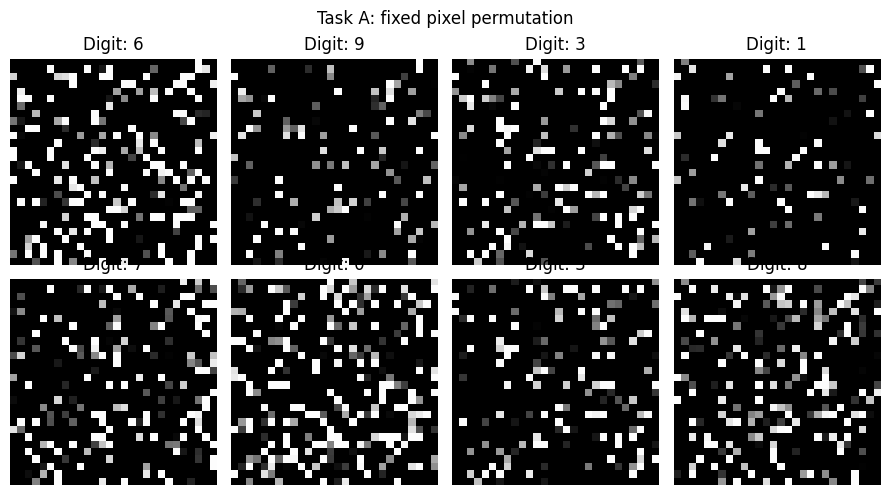

S2 checks passed. Next: S3.


In [14]:
if not globals().get("s2_initialized", False):
    raise RuntimeError("Run the preceding S2 cells first.")

s2_checks_passed = False

# Training and validation must partition the official training examples.
assert np.intersect1d(train_indices, validation_indices).size == 0

combined_indices = np.concatenate([train_indices, validation_indices])
assert np.array_equal(
    np.sort(combined_indices),
    np.arange(len(base_train)),
)

assert np.array_equal(test_indices, np.arange(len(base_test)))

# Check class counts in every split.
split_labels = {
    "train": base_train.targets[torch.from_numpy(train_indices)],
    "validation": base_train.targets[torch.from_numpy(validation_indices)],
    "test": base_test.targets,
}

for split_name, labels in split_labels.items():
    counts = torch.bincount(labels, minlength=10)
    assert counts.shape == (10,)
    assert torch.all(counts > 0)
    print(f"{split_name} class counts:", counts.tolist())

# Check permutation validity and actual output tensors.
task_ids = list(task_specs)

for task_id in task_ids:
    permutation = task_specs[task_id]["pixel_permutation"]
    assert torch.equal(torch.sort(permutation).values, torch.arange(784))

    for split_name in ("train", "validation", "test"):
        image, label = task_datasets[task_id][split_name][0]

        assert image.shape == (1, 28, 28)
        assert image.dtype == torch.float32
        assert torch.isfinite(image).all()
        assert 0.0 <= image.min().item() <= image.max().item() <= 1.0
        assert 0 <= label <= 9

# Confirm the selected tasks have different pixel arrangements.
for first_index, first_task in enumerate(task_ids):
    for second_task in task_ids[first_index + 1:]:
        assert not torch.equal(
            task_specs[first_task]["pixel_permutation"],
            task_specs[second_task]["pixel_permutation"],
        )

# Read a real batch, then restore loader randomness so this preview
# does not alter the order of examples used by later training.
loader_rng_state = train_loader_generator.get_state()

try:
    preview_images, preview_labels = next(iter(train_loader))
finally:
    train_loader_generator.set_state(loader_rng_state)

assert preview_images.shape[1:] == (1, 28, 28)
assert preview_labels.dtype == torch.int64
assert preview_labels.min().item() >= 0
assert preview_labels.max().item() <= 9

print("Batch image shape:", tuple(preview_images.shape))
print("Batch label shape:", tuple(preview_labels.shape))

figure, axes = plt.subplots(2, 4, figsize=(9, 5))

for index, axis in enumerate(axes.flat):
    axis.imshow(preview_images[index, 0], cmap="gray", vmin=0, vmax=1)
    axis.set_title(f"Digit: {preview_labels[index].item()}")
    axis.axis("off")

figure.suptitle(f"Task {current_train_task_id}: fixed pixel permutation")
plt.tight_layout()
plt.show()

s2_checks_passed = True
print("S2 checks passed. Next: S3.")

In [15]:
import math
import torch
from torch import nn
from torch.func import functional_call
from torchvision.models import resnet18

if not globals().get("s2_checks_passed", False):
    raise RuntimeError("Complete the S2 check first.")

if "hypernet" in globals() or "classifier" in globals():
    raise RuntimeError("S3 models already exist. Do not initialize them again.")

if config["initialization"]["method"] != "conventional_initialization_with_output_scaling":
    raise ValueError("These cells implement the development initialization from S0.")

classifier = resnet18(weights=None, num_classes=10)
classifier.conv1 = nn.Conv2d(1, 64, kernel_size=3, stride=1, padding=1, bias=False)
classifier.maxpool = nn.Identity()
classifier = classifier.to(device)

# Train generated weights through the hypernetwork, not these template weights.
classifier.requires_grad_(False)

task_embeddings = {}
task_status = {}
task_buffers = {}

# BatchNorm statistics are separate from trainable weights.
# L1 will clone these starting statistics for each new task.
buffer_template = {
    name: value.detach().clone()
    for name, value in classifier.named_buffers()
}

In [16]:
groups = {"main": [], "shortcut": [], "batchnorm": []}
group_sizes = {group: 0 for group in groups}
parameter_map = {}
modules = dict(classifier.named_modules())

for name, parameter in classifier.named_parameters():
    module_name, parameter_name = name.rsplit(".", 1)
    is_batchnorm = isinstance(modules[module_name], nn.BatchNorm2d)

    if is_batchnorm:
        group = "batchnorm"
    elif "downsample" in module_name:
        group = "shortcut"
    else:
        group = "main"

    # S0's development scaling: small biases and BatchNorm scales near one.
    scale, offset = 0.01, 0.0
    if is_batchnorm and parameter_name == "weight":
        offset = 1.0
    elif not is_batchnorm and parameter_name == "weight":
        fan_in = math.prod(parameter.shape[1:])
        scale = math.sqrt(2 / fan_in)

    start = group_sizes[group]
    stop = start + parameter.numel()

    parameter_map[name] = {
        "group": group, "start": start, "stop": stop,
        "shape": tuple(parameter.shape), "scale": scale, "offset": offset,
    }
    groups[group].append(name)
    group_sizes[group] = stop

In [17]:
total_weights = sum(group_sizes.values())
remaining = config["num_chunks"] - len(groups)

# Give each group one chunk, then divide the remaining chunks proportionally.
shares = {
    group: remaining * size / total_weights
    for group, size in group_sizes.items()
}
chunk_counts = {
    group: 1 + math.floor(shares[group])
    for group in groups
}

# Assign rounding leftovers to the groups with the largest fractional shares.
leftover = config["num_chunks"] - sum(chunk_counts.values())
rounding_order = sorted(
    groups, key=lambda group: shares[group] % 1, reverse=True
)
for group in rounding_order[:leftover]:
    chunk_counts[group] += 1

chunk_widths = {
    group: math.ceil(group_sizes[group] / chunk_counts[group])
    for group in groups
}

for group in groups:
    print(group, ":", chunk_counts[group], "chunks of", chunk_widths[group], "numbers")

main : 195 chunks of 56366 numbers
shortcut : 4 chunks of 43008 numbers
batchnorm : 1 chunks of 9600 numbers


In [18]:
input_width = config["task_embedding_dim"] + config["chunk_embedding_dim"]
widths = [input_width] + config["hidden_widths"]

layers = []
for input_size, output_size in zip(widths[:-1], widths[1:]):
    layers.append(nn.Linear(input_size, output_size))
    layers.append(nn.ReLU())

hypernet = nn.ModuleDict({
    "shared": nn.Sequential(*layers),
    "heads": nn.ModuleDict({
        group: nn.Linear(widths[-1], chunk_widths[group])
        for group in groups
    }),
}).to(device)

chunk_embeddings = nn.Parameter(torch.randn(
    config["num_chunks"],
    config["chunk_embedding_dim"],
    device=device,
))

# L1 will enable these for the first task only.
# L4 will freeze them after that task finishes.
chunk_embeddings.requires_grad_(False)

Parameter containing:
tensor([[ 0.1940,  2.1614, -0.1721,  ..., -1.1835, -1.8029, -1.5808],
        [ 0.8387,  1.4192,  0.6469,  ..., -0.8146,  0.2502, -0.4273],
        [ 1.1044, -1.1028,  0.5543,  ..., -0.6463,  0.0749,  0.1939],
        ...,
        [-0.9932, -0.8017,  1.9661,  ..., -0.6168,  0.6920,  0.3391],
        [ 0.5063,  0.5746,  0.7750,  ...,  0.2995, -1.3159, -1.2063],
        [-0.4656,  1.7651, -0.1238,  ..., -0.1481,  1.5505, -0.3742]],
       device='cuda:0')

In [19]:
for layer in hypernet["shared"]:
    if isinstance(layer, nn.Linear):
        nn.init.kaiming_normal_(layer.weight, nonlinearity="relu")
        nn.init.zeros_(layer.bias)

for head in hypernet["heads"].values():
    nn.init.xavier_normal_(head.weight)
    nn.init.zeros_(head.bias)

hypernet_count = sum(parameter.numel() for parameter in hypernet.parameters())
chunk_count = chunk_embeddings.numel()

# Float32 uses four bytes per number.
# Hypernetwork: weights, gradients, two Adam states, and one reference copy.
estimated_bytes = 4 * (
    5 * hypernet_count + 3 * total_weights + 4 * chunk_count
)

print(f"Classifier parameters: {total_weights:,}")
print(f"Hypernetwork parameters: {hypernet_count:,}")
print(f"Chunk-code parameters: {chunk_count:,}")
print(f"Approximate core training storage: {estimated_bytes / 1024**3:.2f} GiB")
print("Initialization: development approximation, not Hyperfan.")

Classifier parameters: 11,172,810
Hypernetwork parameters: 56,076,590
Chunk-code parameters: 6,400
Approximate core training storage: 1.17 GiB
Initialization: development approximation, not Hyperfan.


In [20]:
def generate_weights(task_code, network, chunk_codes):
    """Turn one task code into a dictionary of classifier weights."""
    generated_groups = {}
    first_chunk = 0

    for group in groups:
        count = chunk_counts[group]
        codes = chunk_codes[first_chunk:first_chunk + count]

        # Repeat the task code once per chunk, then join the two codes.
        repeated_task = task_code.unsqueeze(0).expand(count, -1)
        inputs = torch.cat([repeated_task, codes], dim=1)

        features = network["shared"](inputs)
        raw_weights = network["heads"][group](features).reshape(-1)

        # Remove padding from the final chunk.
        generated_groups[group] = raw_weights[:group_sizes[group]]
        first_chunk += count

    weights = {}
    for name, entry in parameter_map.items():
        values = generated_groups[entry["group"]]
        values = values[entry["start"]:entry["stop"]]
        values = values.reshape(entry["shape"])
        weights[name] = values * entry["scale"] + entry["offset"]

    return weights

In [21]:
s3_checks_passed = False

check_code = torch.zeros(config["task_embedding_dim"], device=device)
check_weights = generate_weights(check_code, hypernet, chunk_embeddings)

expected_parameters = dict(classifier.named_parameters())
assert set(check_weights) == set(expected_parameters)
assert sum(chunk_counts.values()) == config["num_chunks"]

for name, weight in check_weights.items():
    assert weight.shape == expected_parameters[name].shape
    assert weight.requires_grad
    assert torch.isfinite(weight).all()

check_buffers = {
    name: value.clone() for name, value in buffer_template.items()
}

previous_mode = classifier.training
classifier.eval()

try:
    with torch.no_grad():
        check_images = torch.zeros(2, 1, 28, 28, device=device)
        check_scores = functional_call(
            classifier, (check_weights, check_buffers),
            (check_images,), strict=True,
        )

    assert check_scores.shape == (2, 10)
    assert torch.isfinite(check_scores).all()
finally:
    classifier.train(previous_mode)

del check_weights, check_buffers, check_images, check_scores, check_code

s3_checks_passed = True
print("S3 checks passed: every weight matches, and two images produce 2 x 10 scores.")

S3 checks passed: every weight matches, and two images produce 2 x 10 scores.
